# Analiza Eksploracyjna Danych (EDA) dla eksperymentu SSVEP
Notatnik ma na celu wczytanie danych zebranych z urządzenia EEG zapisanych w formacie `.fif` i przeprowadzenie podstawowej analizy częstotliwościowej sygnału (FFT, PSD) w tym porównanie sygnału surowego oraz sygnału po zaaplikowaniu filtru Savitzky-Golay.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, welch
from scipy.fft import fft, fftfreq
import os
import sys
import mne 

sys.path.append(os.path.abspath('../experiment'))

from src.config.bci_config import SAMPLING_RATE, TARGET_CHANNELS, SG_WINDOW, SG_POLYORDER

plt.rcParams['figure.figsize'] = (12, 6)
plt.style.use('seaborn-v0_8-darkgrid')

## 1. Wczytanie danych .fif z eksperymentu
Używamy pakietu `mne`, do załadowania zapisanego wcześniej pliku `.fif`.

In [2]:
filename = '../experiment/badanie_eeg.fif'

try:
    raw = mne.io.read_raw_fif(filename, preload=True)
    data = raw.get_data() 
    print(f"Dane odczytane poprawnie. Wymiary: {data.shape} (kanały, próbki)")
except FileNotFoundError:
    print(f"Nie można znaleźć pliku '{filename}'.")
    # Generator prowizorycznych danych, jeśli brak:
    t_mock = np.linspace(0, 5, 5 * SAMPLING_RATE, endpoint=False)
    data = np.random.randn(16, len(t_mock)) + 5 * np.sin(2 * np.pi * 10 * t_mock)

num_samples = data.shape[1]
time = np.arange(num_samples) / SAMPLING_RATE

# Skupiamy się na pierwszym kanale z wyznaczonych w TARGET_CHANNELS
ch_idx = TARGET_CHANNELS[0]
raw_signal = data[ch_idx, :]
print(f"Analizujemy kanał nr {ch_idx}")

Nie można znaleźć pliku '../experiment/badanie_eeg.fif'.
Analizujemy kanał nr 1


## 2. Porównanie sygnału surowego względem Savitzky-Golay (Filtrowanego)
Wyciągamy średnią ze wszystkich kanałów (CAR) na surowym sygnale, a następnie aplikujemy interesujący nas filtr `savgol_filter`.

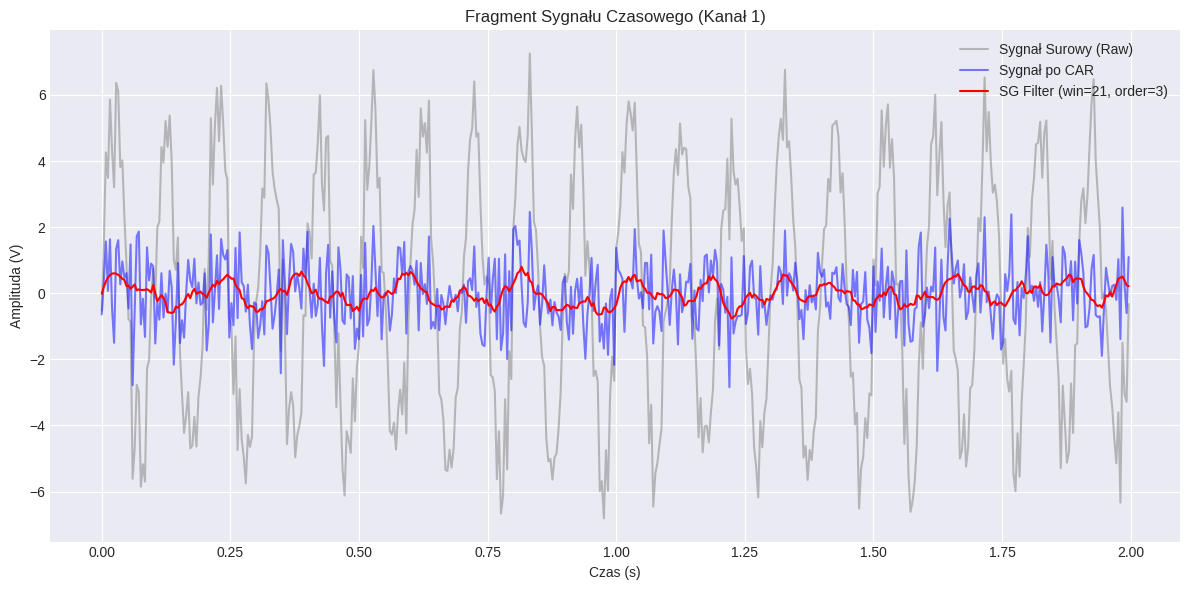

In [12]:
# Operacja Common Average Reference (CAR)
mean_signal = np.mean(data, axis=0)
car_signal = raw_signal - mean_signal

# Nakładanie filtra Savitzky-Golay
filtered_signal = savgol_filter(car_signal, window_length=SG_WINDOW, polyorder=SG_POLYORDER)

# Renderowanie wykresów dziedziny czasu
plt.figure()
# Parametr do pokazania tylko niewielkiego wycinka czasowego dla widoczności, np. 2 pierwsze sekundy
limit = min(2 * SAMPLING_RATE, num_samples)

plt.plot(time[:limit], raw_signal[:limit], label="Sygnał Surowy (Raw)", alpha=0.5, color='gray')
plt.plot(time[:limit], car_signal[:limit], label="Sygnał po CAR", alpha=0.5, color='blue')
plt.plot(time[:limit], filtered_signal[:limit], label=f"SG Filter (win={SG_WINDOW}, order={SG_POLYORDER})", linewidth=1.5, color='red')

plt.title(f"Fragment Sygnału Czasowego (Kanał {ch_idx})")
plt.xlabel("Czas (s)")
plt.ylabel("Amplituda (V)") # w .fif mne zapisuje napięcia standardowo w Voltach, ew. podziel/pomnóż wg. skali w Twoim streamie
plt.legend()
plt.tight_layout()
plt.show()

## 3. Analiza Częstotliwości za pomocą Szybkiej Transformaty Fouriera (FFT)
Obliczamy widmo amplitudowe za pomocą FFT i rysujemy wynik w przedziale do 40 Hz (optymalne pasmo w badaniach SSVEP).

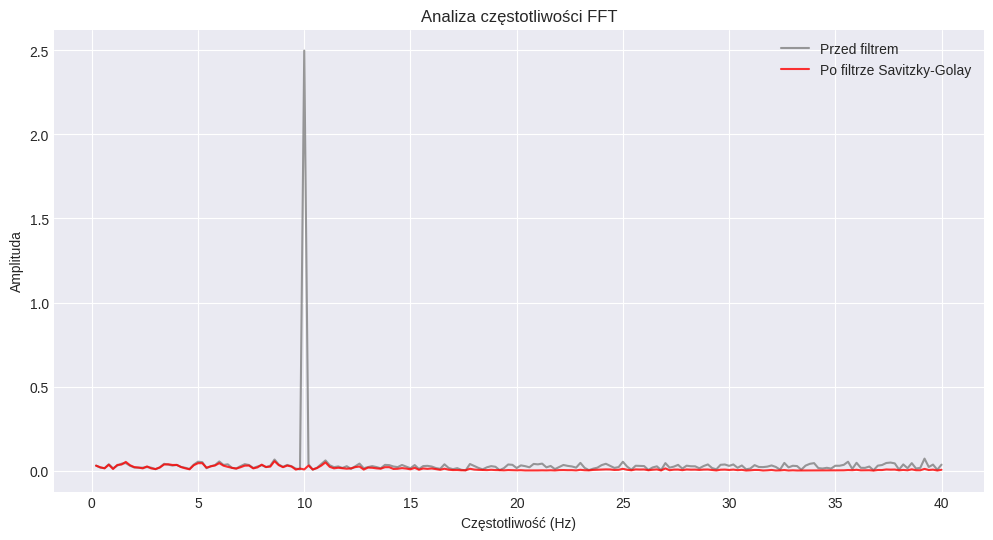

In [4]:
def plot_fft(signal, title, color):
    # Obliczanie widma amplitudowego
    N = len(signal)
    signal_fft = fft(signal)
    freqs = fftfreq(N, 1 / SAMPLING_RATE)

    # Bierzemy pod uwagę tylko częstotliwości dodatnie
    pos_mask = freqs > 0
    freqs = freqs[pos_mask]
    amplitudes = np.abs(signal_fft[pos_mask]) / N

    # Zawężanie widma do SSVEP
    mask_ssvep = freqs <= 40

    plt.plot(freqs[mask_ssvep], amplitudes[mask_ssvep], label=title, color=color, alpha=0.8)

plt.figure(figsize=(12, 6))
plot_fft(raw_signal, "Przed filtrem", 'gray')
plot_fft(filtered_signal, "Po filtrze Savitzky-Golay", 'red')

plt.title("Analiza częstotliwości FFT")
plt.xlabel("Częstotliwość (Hz)")
plt.ylabel("Amplituda")
plt.legend()
plt.show()

## 4. Wykres Gęstości Widmowej Mocy (Power Spectral Density - PSD)
Porównanie sygnału surowego oraz przefiltrowanego za pomocą metody Welcha.

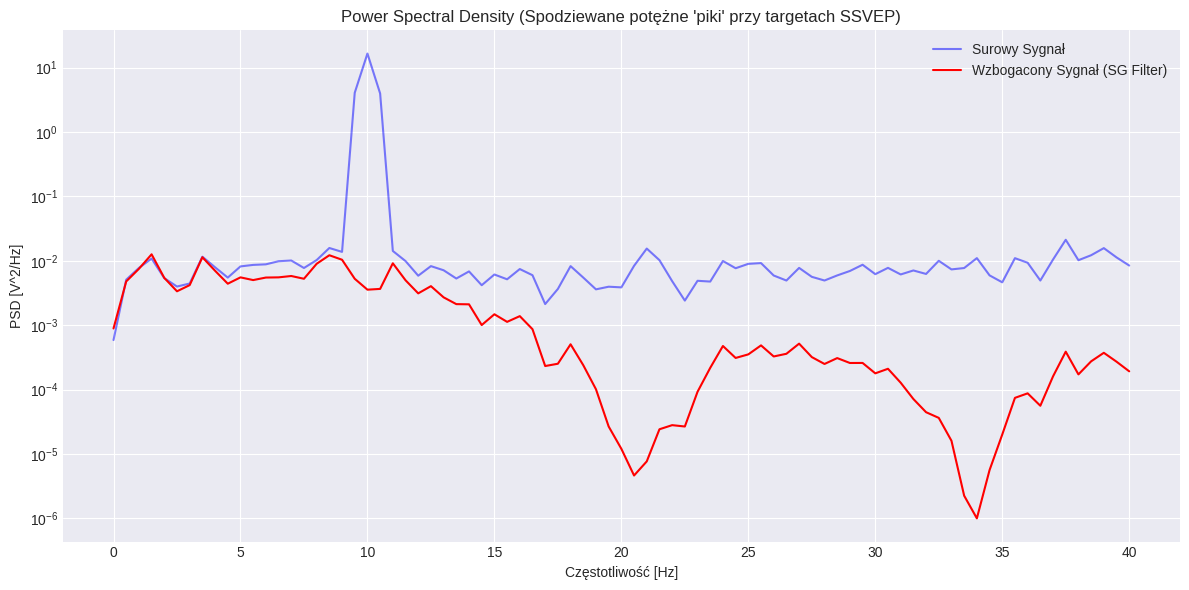

In [5]:
# Szacowna długość fragmentu dla Welcha ustalamy np. na 2 sekundy stąd nperseg = 2 * SAMPLING_RATE
nperseg = min(2 * SAMPLING_RATE, len(raw_signal))

# Obliczanie Welcha dla obydwu sygnałów
f_raw, psd_raw = welch(raw_signal, fs=SAMPLING_RATE, nperseg=nperseg)
f_filt, psd_filt = welch(filtered_signal, fs=SAMPLING_RATE, nperseg=nperseg)

# Widmo SSVEP max 40 Hz
plot_range_raw = f_raw <= 40
plot_range_filt = f_filt <= 40

plt.figure(figsize=(12, 6))
plt.semilogy(f_raw[plot_range_raw], psd_raw[plot_range_raw], label="Surowy Sygnał", color='blue', alpha=0.5)
plt.semilogy(f_filt[plot_range_filt], psd_filt[plot_range_filt], label=f"Wzbogacony Sygnał (SG Filter)", color='red', linewidth=1.5)

plt.title("Power Spectral Density (Spodziewane potężne 'piki' przy targetach SSVEP)")
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("PSD [V^2/Hz]")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Klasyfikacja przy użyciu Canonical Correlation Analysis (CCA)
Skrypt symuluje, w jaki sposób Twój klasyfikator `CCAPredictor` w aplikacji przetwarza wycięte okno sygnału i podejmuje decyzję o tym, do jakiej częstotliwości należy pobudzenie.
CCA poszukuje maksymalnej korelacji między odczytami EEG, a matematycznie wygenerowanymi referencyjnymi sygnałami sinus/cosinus (w tym z ich wybranymi harmonikami).

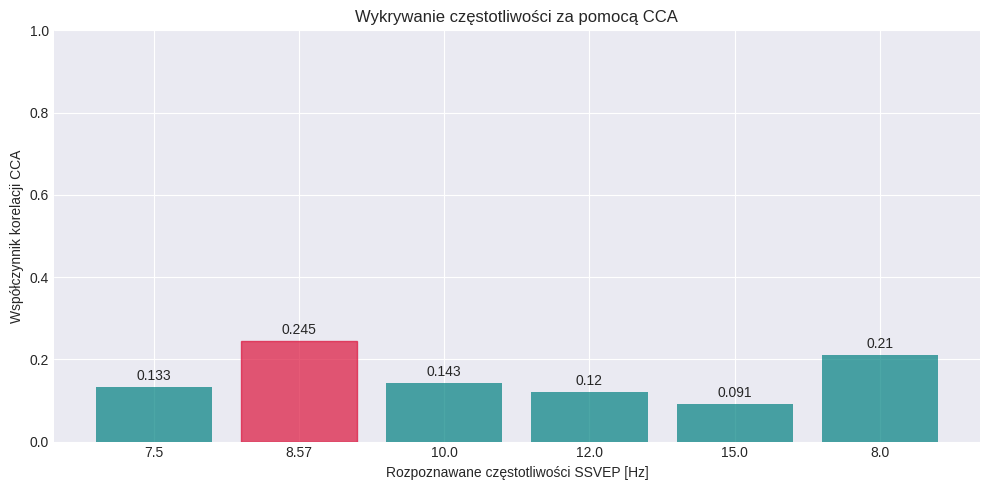

Klasyfikator wskazał na podstawie korelacji częstotliwość: 8.57 Hz


In [15]:
from sklearn.cross_decomposition import CCA
from src.config.bci_config import FREQS, WINDOW_TIME_FRAME, SAMPLES_PER_WINDOW

# 1. Definiujemy funkcje do generowania sygnałów referencyjnych tak jak jest w `CCAPredictor`
def generate_reference_signals(length, freq, sampling_rate, num_harmonics=2):
    t = np.arange(length) / sampling_rate
    y = []
    for i in range(1, num_harmonics + 1):
        y.append(np.sin(2 * np.pi * i * freq * t))
        y.append(np.cos(2 * np.pi * i * freq * t))
    return np.array(y).T


car_all_channels = data - np.mean(data, axis=0) # CAR na wszystkich kanałach
X_target_channels = car_all_channels[TARGET_CHANNELS, :] # (kanały, próbki)
filtered_all = savgol_filter(X_target_channels, window_length=SG_WINDOW, polyorder=SG_POLYORDER, axis=1)

epoch_X = filtered_all[:, :SAMPLES_PER_WINDOW].T

cca = CCA(n_components=1)
correlations = {}

for freq in FREQS:
    Y_ref = generate_reference_signals(SAMPLES_PER_WINDOW, freq, SAMPLING_RATE, num_harmonics=2)
    
    # Trenujemy i transformujemy model CCA
    cca.fit(epoch_X, Y_ref)
    Xc, Yc = cca.transform(epoch_X, Y_ref)
    
    # Obliczamy współczynnik korelacji
    corr = np.corrcoef(Xc[:, 0], Yc[:, 0])[0, 1]
    correlations[freq] = corr

# 4. Wyświetlanie wyników korelacji
freqs_list = list(correlations.keys())
corr_values = list(correlations.values())

plt.figure(figsize=(10, 5))
bars = plt.bar([str(f) for f in freqs_list], corr_values, color='teal', alpha=0.7)

# Najwyższa korelacja na czerwono na wykresie
best_idx = np.argmax(corr_values)
bars[best_idx].set_color('crimson')

plt.title("Wykrywanie częstotliwości za pomocą CCA")
plt.xlabel("Rozpoznawane częstotliwości SSVEP [Hz]")
plt.ylabel("Współczynnik korelacji CCA")

# Dodajemy wartości na słupkach
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 3), ha='center', va='bottom')

plt.ylim(0, max(max(corr_values) + 0.1, 1.0))
plt.tight_layout()
plt.show()

best_freq = freqs_list[best_idx]
print(f"Klasyfikator wskazał na podstawie korelacji częstotliwość: {best_freq} Hz")